# LSTM Model

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import LSTM,Dense, Flatten, Bidirectional, GRU, SimpleRNN

In [4]:
def prepare_data(timeseries_data,n_features):
  x, y =[], []
  for i in range(len(timeseries_data)):
    end_ix = i +n_features
    if end_ix > len(timeseries_data) -1:
      break
    seq_x, seq_y = timeseries_data[i:end_ix], timeseries_data[end_ix]
    x.append(seq_x)
    y.append(seq_y)
  return np.array(x),np.array(y)

In [5]:
timeseries_data =[100,120,135,145,150,160,185,200,225,300]
n_steps = 3
x, y = prepare_data(timeseries_data, n_steps)

In [6]:
print(x)

[[100 120 135]
 [120 135 145]
 [135 145 150]
 [145 150 160]
 [150 160 185]
 [160 185 200]
 [185 200 225]]


In [7]:
print(y)

[145 150 160 185 200 225 300]


In [8]:
x.shape

(7, 3)

In [9]:
y.shape

(7,)

In [10]:
# Reshape from [sample, timesteps] into [samples, timesteps, features]

n_features = 1
x = x.reshape(x.shape[0],x.shape[1],n_features)

# here x.shape[0] =7,
# here x.shape[1] =3 (every time consider 3 parameters)
# here n_features =1 (no of output )

In [11]:
model = Sequential()
model.add(LSTM(50,activation ='relu',return_sequences =True, input_shape =(n_steps,n_features)))
model.add(LSTM(50,activation ='relu'))
model.add(Dense(1))
model.compile(optimizer ='adam',loss ='mae')
model.fit(x,y,epochs =200, verbose =1)

Epoch 1/200
1/1 [==============================] - 4s 4s/step - loss: 187.3118
Epoch 2/200
1/1 [==============================] - 0s 21ms/step - loss: 183.6776
Epoch 3/200
1/1 [==============================] - 0s 20ms/step - loss: 179.4021
Epoch 4/200
1/1 [==============================] - 0s 23ms/step - loss: 174.4024
Epoch 5/200
1/1 [==============================] - 0s 21ms/step - loss: 169.4108
Epoch 6/200
1/1 [==============================] - 0s 19ms/step - loss: 165.2958
Epoch 7/200
1/1 [==============================] - 0s 20ms/step - loss: 161.6402
Epoch 8/200
1/1 [==============================] - 0s 22ms/step - loss: 157.9656
Epoch 9/200
1/1 [==============================] - 0s 20ms/step - loss: 153.9943
Epoch 10/200
1/1 [==============================] - 0s 23ms/step - loss: 149.6401
Epoch 11/200
1/1 [==============================] - 0s 20ms/step - loss: 145.1913
Epoch 12/200
1/1 [==============================] - 0s 18ms/step - loss: 140.7496
Epoch 13/200
1/1 [=========

In [12]:
# predictioon for the next 25 revenue data

x_input = np.array([200,225,300])
temp_input = list(x_input)
output = []

i = 0
while(i<25):
  if(len(temp_input)>3):
    x_input = np.array(temp_input[1:])
    print("{} day input {}".format(i, x_input))
    x_input = x_input.reshape((1,n_steps,n_features))
    yhat =model.predict(x_input, verbose =0)
    print("{} day input {}".format(i, yhat))
    temp_input.append(yhat[0][0])
    temp_input = temp_input[1:]
    output.append(yhat[0][0])
    i = i+1
  else:
    x_input =x_input.reshape((1, n_steps,n_features))
    yhat =model.predict(x_input, verbose =0)
    print(yhat[0])
    temp_input.append(yhat[0][0])
    output.append(yhat[0][0])
    i = i+1
print(output)


[303.4746]
1 day input [225.         300.         303.47460938]
1 day input [[359.1884]]
2 day input [300.         303.47460938 359.18838501]
2 day input [[442.38245]]
3 day input [303.4746  359.1884  442.38245]
3 day input [[487.2752]]
4 day input [359.1884  442.38245 487.2752 ]
4 day input [[583.2349]]
5 day input [442.38245 487.2752  583.2349 ]
5 day input [[695.29926]]
6 day input [487.2752  583.2349  695.29926]
6 day input [[796.74536]]
7 day input [583.2349  695.29926 796.74536]
7 day input [[948.73474]]
8 day input [695.29926 796.74536 948.73474]
8 day input [[1118.2949]]
9 day input [ 796.74536  948.73474 1118.2949 ]
9 day input [[1303.1329]]
10 day input [ 948.73474 1118.2949  1303.1329 ]
10 day input [[1542.7069]]
11 day input [1118.2949 1303.1329 1542.7069]
11 day input [[1813.4567]]
12 day input [1303.1329 1542.7069 1813.4567]
12 day input [[2126.697]]
13 day input [1542.7069 1813.4567 2126.697 ]
13 day input [[2508.839]]
14 day input [1813.4567 2126.697  2508.839 ]
14 day 

In [13]:
timeseries_data

[100, 120, 135, 145, 150, 160, 185, 200, 225, 300]

In [14]:
output

[303.4746,
 359.1884,
 442.38245,
 487.2752,
 583.2349,
 695.29926,
 796.74536,
 948.73474,
 1118.2949,
 1303.1329,
 1542.7069,
 1813.4567,
 2126.697,
 2508.839,
 2948.5066,
 3465.3347,
 4080.9336,
 4797.5083,
 5642.1772,
 6639.4956,
 7807.3853,
 9183.474,
 10803.546,
 12705.845,
 14945.577]

In [18]:
#we are checking whether the predicted is correct or wrong by seeing the graph curve
import matplotlib.pyplot as plt
day_new = np.arange(0,10)
day_pred = np.arange(10,35)

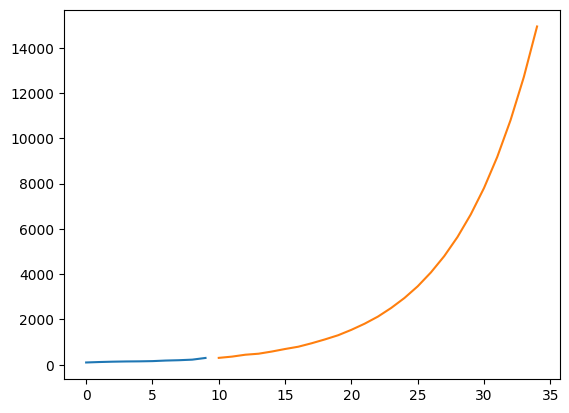

In [19]:
plt.plot(day_new, timeseries_data)
plt.plot(day_pred,output)
plt.show()